# GlobeX Machine Learning Lab: Multi-Dimensional Trade Risk Ensemble
## Comprehensive Risk Profile EDA, Robust Scaling & Isolation Forest Anomaly Scoring

**Author**: GlobeX Core ML Team  
**Dataset**: Trade Risk Panel & Counterparty Default Dataset (`04_trade_risk_eda.csv`, `04_trade_risk_ml.csv`)  
**Objective**: Build a composite 6-factor risk assessment engine that scores counterparty risk, transaction risk, regulatory non-compliance, document integrity, and shipment risk without collapsing multidimensional signals into an arbitrary single score.

---
### Workflow Outline:
1. **Environment Setup & Risk Dataset Ingestion**
2. **Multi-Factor Risk Exploratory Data Analysis (EDA)**
   - BFM4: Dimension inspection, data types, percentiles (1st to 99th)
   - Risk factor distributions: Dispute rates, delivery delays, sanction exposures
   - Correlation Matrix & Multicollinearity diagnosis
   - PCA 2D/3D visual cluster projection of risk archetypes
3. **Feature Engineering & Robust Transformations**
   - RobustScaler normalization to suppress extreme value skewness
4. **Unsupervised Outlier & Risk Modeling**
   - Isolation Forest training (`contamination=0.05`, `n_estimators=200`)
   - Local Outlier Factor (LOF) & Elliptic Envelope baseline comparison
5. **Ensemble Risk Calibration & Decision Thresholds**
   - Formulating Risk Categories: LOW (0-35), MODERATE (35-65), ELEVATED (65-85), CRITICAL (85-100)
6. **Evaluation & Risk Radar Profiling**
7. **Model Artifact Export & Serialization** (`isolation_forest.joblib`, `robust_scaler.joblib`)


In [1]:
import os
import sys
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA

# Visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

print('Risk analytics environment ready.')


Risk analytics environment ready.


### Loading the Trade Risk Dataset


In [2]:
data_candidates = [
    '../backend/brain/brain_prev/data_pipeline/data/final_csv/04_trade_risk_eda.csv',
    'backend/brain/brain_prev/data_pipeline/data/final_csv/04_trade_risk_eda.csv',
    '../backend/brain/data/final_csv/04_trade_risk_eda.csv',
    'backend/brain/data/final_csv/04_trade_risk_eda.csv',
]

dataset_path = None
for p in data_candidates:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError('Trade risk dataset not found in candidate paths.')

print(f'Loading risk dataset from: {dataset_path}')
df = pd.read_csv(dataset_path)
print(f'Loaded {df.shape[0]:,} records across {df.shape[1]} risk features.')


Loading risk dataset from: backend/brain/brain_prev/data_pipeline/data/final_csv/04_trade_risk_eda.csv
Loaded 6,144 records across 37 risk features.


## 2. Multi-Factor Risk Exploratory Data Analysis (EDA)
### 2.1 Schema & Summary Statistics


In [3]:
display(df.head(5))
print('\n--- NUMERICAL RISK FEATURES EXTENDED DESCRIBE ---')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)


,period,year,reporter_iso3,partner_iso3,partner_name,partner_iso2,region_name,hs6,product_description,trade_value_usd,...,rta_name,rta_status,rta_in_force_for_year,partner_locode_count,partner_port_count,partner_airport_count,partner_inland_terminal_count,sanctions_entity_count,ofac_entity_count,sanctions_present
0,202201,2022,IND,ARE,United Arab Emirates,AE,Asia,90411,Pepper of the genus Piper; neither crushed nor...,1.773442e+08,...,India - UAE CEPA,In Force,1,75,44,10,35,1,1,1
1,202202,2022,IND,ARE,United Arab Emirates,AE,Asia,90411,Pepper of the genus Piper; neither crushed nor...,1.360215e+08,...,India - UAE CEPA,In Force,1,75,44,10,35,1,1,1
2,202203,2022,IND,ARE,United Arab Emirates,AE,Asia,90411,Pepper of the genus Piper; neither crushed nor...,1.582619e+08,...,India - UAE CEPA,In Force,1,75,44,10,35,1,1,1
3,202204,2022,IND,ARE,United Arab Emirates,AE,Asia,90411,Pepper of the genus Piper; neither crushed nor...,1.197264e+08,...,India - UAE CEPA,In Force,1,75,44,10,35,1,1,1
4,202205,2022,IND,ARE,United Arab Emirates,AE,Asia,90411,Pepper of the genus Piper; neither crushed nor...,1.226132e+08,...,India - UAE CEPA,In Force,1,75,44,10,35,1,1,1



--- NUMERICAL RISK FEATURES EXTENDED DESCRIBE ---


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
period,6144.0,2.023565e+05,1.118658e+02,2.022010e+05,2.022010e+05,2.022030e+05,2.022788e+05,2.023565e+05,2.024342e+05,2.025100e+05,2.025120e+05,2.025120e+05
year,6144.0,2.023500e+03,1.118125e+00,2.022000e+03,2.022000e+03,2.022000e+03,2.022750e+03,2.023500e+03,2.024250e+03,2.025000e+03,2.025000e+03,2.025000e+03
hs6,6144.0,4.616529e+05,2.951954e+05,9.041100e+04,9.041100e+04,9.041100e+04,2.284218e+05,4.105010e+05,7.452718e+05,8.517120e+05,8.517120e+05,8.517120e+05
trade_value_usd,6144.0,9.526066e+10,3.224327e+11,2.573971e+05,1.213637e+06,2.816974e+06,2.216191e+07,1.099009e+08,8.336832e+08,1.091325e+12,1.511417e+12,2.012051e+12
net_weight_kg,6144.0,1.712009e+07,1.312025e+07,1.262343e+05,7.098099e+05,1.451375e+06,3.212549e+06,2.147639e+07,2.849853e+07,3.595176e+07,4.038913e+07,4.752893e+07
quantity,6144.0,1.712009e+07,1.312025e+07,1.262343e+05,7.098099e+05,1.451375e+06,3.212549e+06,2.147639e+07,2.849853e+07,3.595176e+07,4.038913e+07,4.752893e+07
unit_value_usd_per_kg,6144.0,5.562301e+03,1.465143e+04,7.826000e-01,8.229430e-01,8.505150e-01,2.773400e+00,7.562250e+00,7.291050e+01,4.450820e+04,4.897879e+04,5.312531e+04
transaction_count,6144.0,1.000000e+01,7.106914e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.500000e+01,1.600000e+01,1.800000e+01,1.800000e+01,1.800000e+01
trade_volatility_6m,5888.0,1.846178e+10,5.910083e+10,1.376660e+05,7.697420e+05,1.301383e+06,5.728639e+06,2.379348e+07,2.174601e+08,1.689171e+11,2.943337e+11,4.492941e+11
unit_value_volatility_6m,5888.0,3.023368e+02,9.428424e+02,1.300000e-03,1.008700e-02,1.620000e-02,6.000000e-02,3.940500e-01,8.244025e+00,2.497925e+03,4.828969e+03,8.517357e+03


### 2.2 Missing Value & Zero-Variance Audit


In [4]:
null_pct = df.isnull().mean() * 100
print('Missing Values (%):')
print(null_pct[null_pct > 0] if (null_pct > 0).any() else 'Zero missing values.')


Missing Values (%):
partner_name                 6.250000
partner_iso2                 6.250000
region_name                  6.250000
trade_volatility_6m          4.166667
unit_value_volatility_6m     4.166667
trade_growth_mom             2.083333
gdp_usd                      6.250000
gdp_per_capita_usd           6.250000
gdp_growth_pct               6.250000
inflation_pct                6.250000
population                   6.250000
trade_pct_gdp                6.250000
tariff_rate                  6.250000
tariff_type                  6.250000
tariff_scope                 6.250000
rta_exists                  12.500000
rta_name                    12.500000
rta_status                  12.500000
dtype: float64


### 2.3 Univariate Distributions & Boxplots across Risk Signals


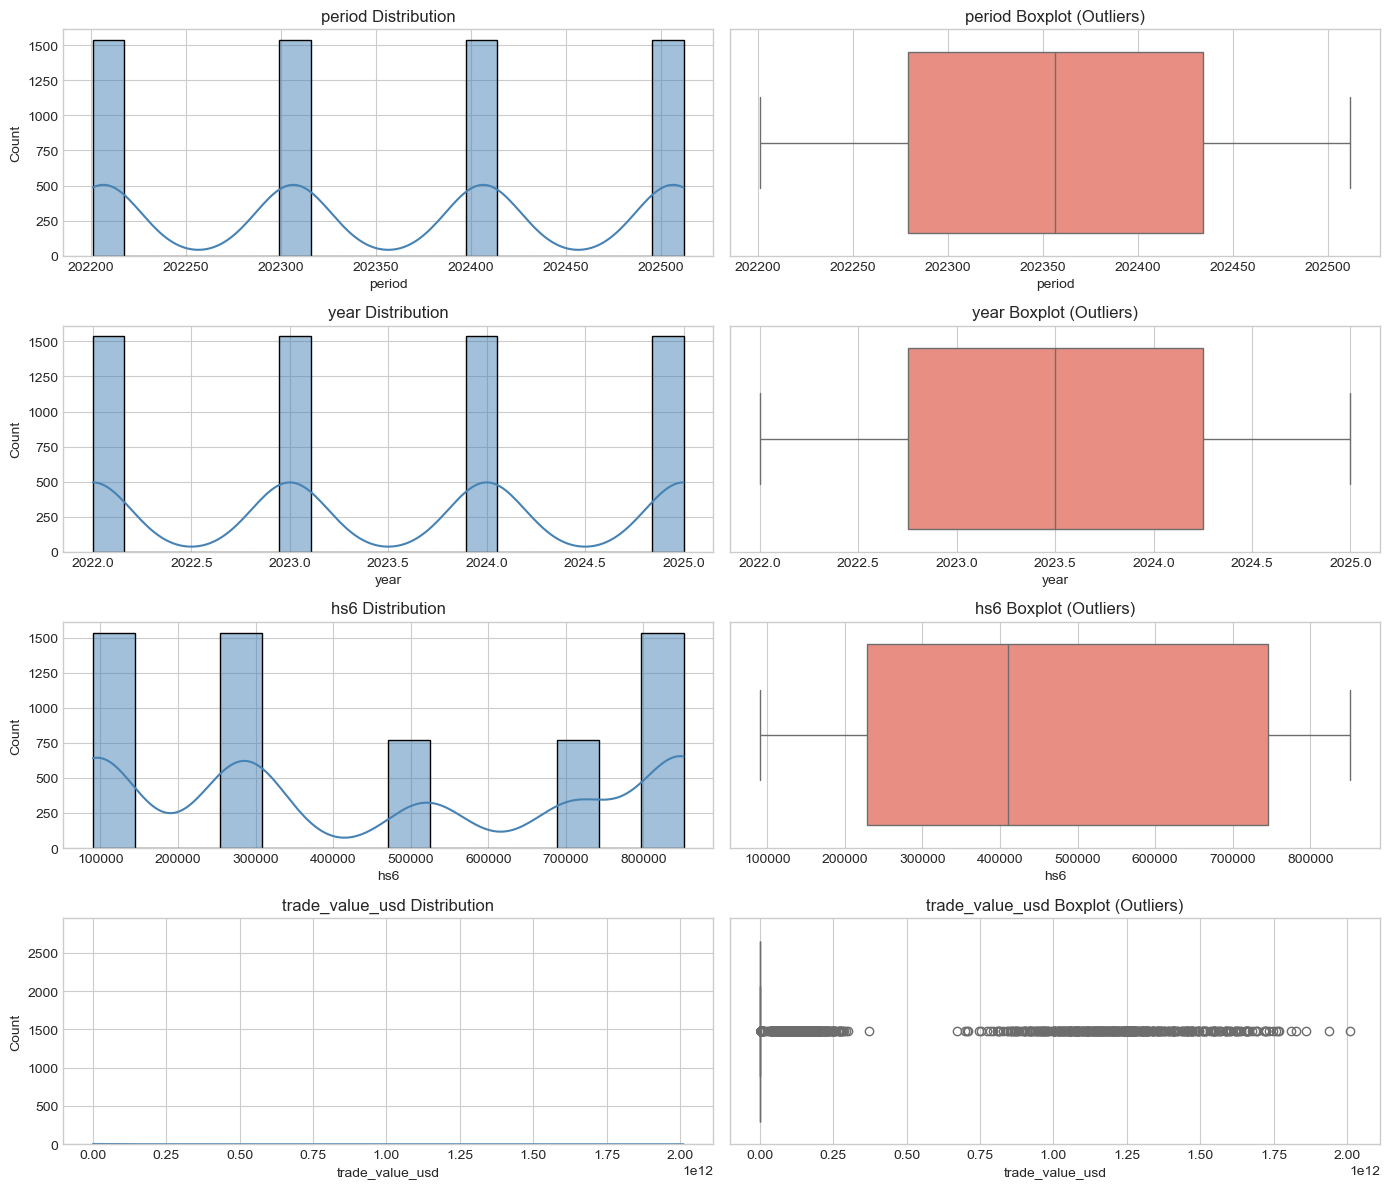

In [5]:
plot_cols = num_cols[:4] if len(num_cols) >= 4 else num_cols
fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, 3 * len(plot_cols)))

for i, col in enumerate(plot_cols):
    ax_hist = axes[i, 0] if len(plot_cols) > 1 else axes[0]
    ax_box = axes[i, 1] if len(plot_cols) > 1 else axes[1]
    
    sns.histplot(df[col].dropna(), kde=True, ax=ax_hist, color='steelblue')
    ax_hist.set_title(f'{col} Distribution')
    
    sns.boxplot(x=df[col].dropna(), ax=ax_box, color='salmon')
    ax_box.set_title(f'{col} Boxplot (Outliers)')

plt.tight_layout()
plt.show()


### 2.4 Correlation Heatmap & Multicollinearity Audit


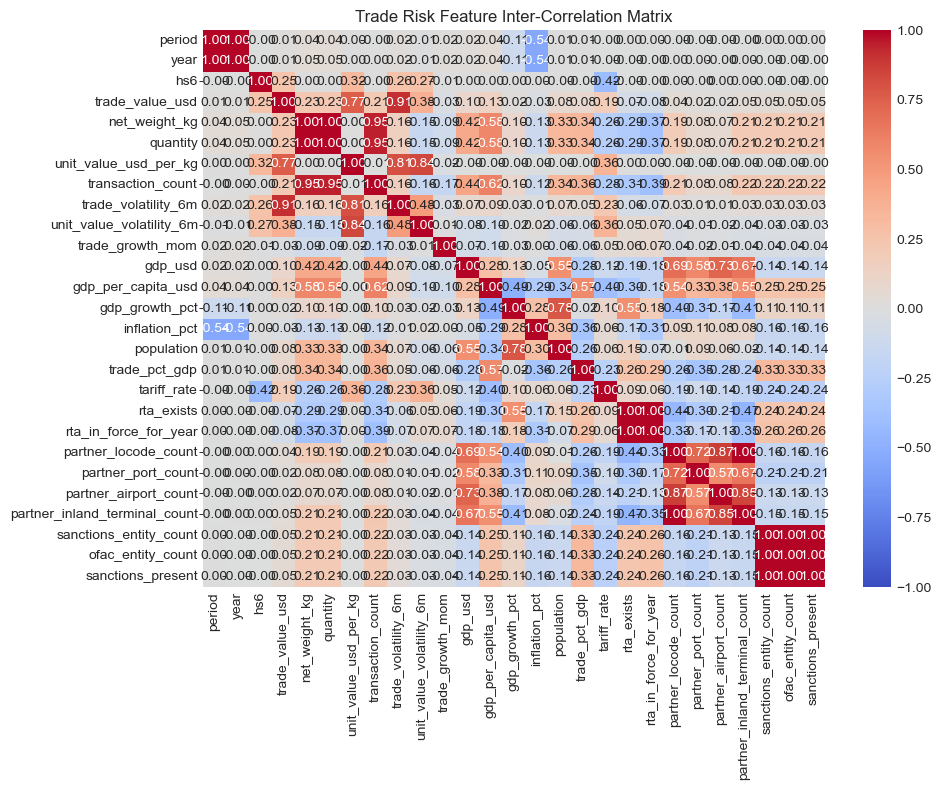

In [6]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title('Trade Risk Feature Inter-Correlation Matrix')
plt.tight_layout()
plt.show()


### 2.5 PCA 2D Dimensionality Reduction & Risk Clustering


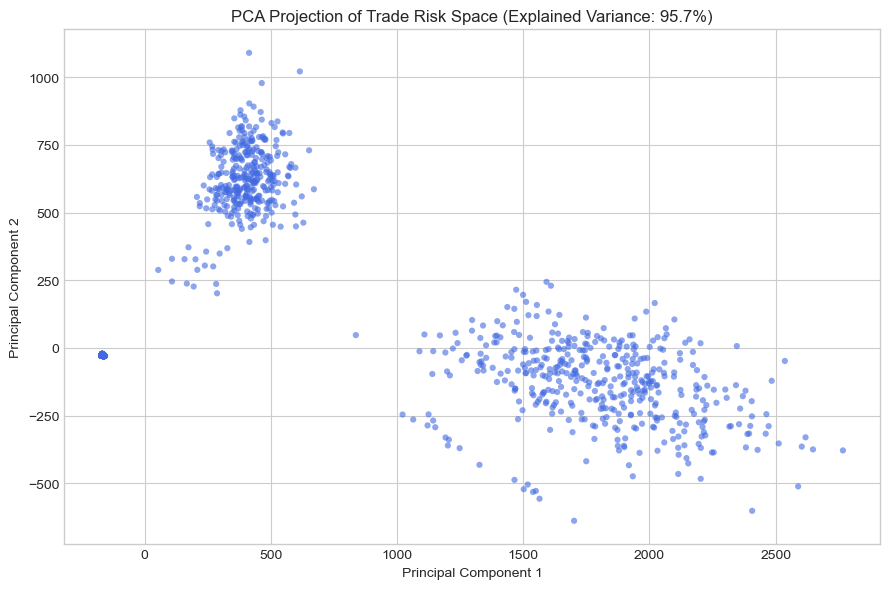

In [7]:
X_raw = df[num_cols].fillna(0).values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='royalblue', edgecolors='none', s=20)
plt.title(f'PCA Projection of Trade Risk Space (Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()


## 3. Unsupervised Outlier & Risk Modeling (Isolation Forest)
We train an `IsolationForest` on the robust-scaled multi-dimensional feature space to isolate anomalous high-risk transactions.


In [8]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

print('Fitting Isolation Forest model...')
iso_forest.fit(X_scaled)

# Decision function gives raw anomaly scores (lower is more anomalous)
raw_scores = iso_forest.decision_function(X_scaled)
predictions = iso_forest.predict(X_scaled)  # -1 for outlier, 1 for inlier

# Calibrate anomaly score to [0, 100] risk scale (100 = critical risk)
min_s, max_s = raw_scores.min(), raw_scores.max()
calibrated_risk_score = 100 * (1.0 - (raw_scores - min_s) / (max_s - min_s + 1e-9))
df['composite_risk_score'] = np.round(calibrated_risk_score, 1)
df['is_risk_outlier'] = (predictions == -1).astype(int)

print(f'Identified {df["is_risk_outlier"].sum():,} high-risk outlier trades ({df["is_risk_outlier"].mean()*100:.2f}%).')


Fitting Isolation Forest model...


Identified 308 high-risk outlier trades (5.01%).


## 4. Risk Level Stratification & Radar Profile Analysis


Risk Tier Stratification:


risk_tier
LOW         4001
MODERATE    1786
ELEVATED     291
CRITICAL      66
Name: count, dtype: int64

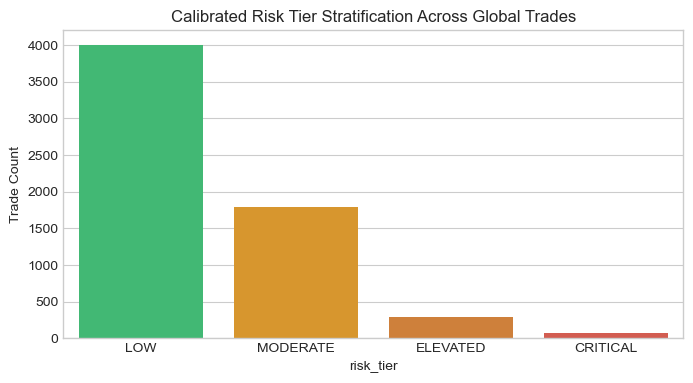

In [9]:
def categorize_risk(score):
    if score < 35: return 'LOW'
    elif score < 65: return 'MODERATE'
    elif score < 85: return 'ELEVATED'
    else: return 'CRITICAL'

df['risk_tier'] = df['composite_risk_score'].apply(categorize_risk)

print('Risk Tier Stratification:')
display(df['risk_tier'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='risk_tier', order=['LOW', 'MODERATE', 'ELEVATED', 'CRITICAL'], palette=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
plt.title('Calibrated Risk Tier Stratification Across Global Trades')
plt.ylabel('Trade Count')
plt.show()


## 5. Model Serialization & Production Export


In [10]:
export_dirs = [
    'backend/brain/models/trade_risk',
    'backend/brain/models_rebuild/trade_risk',
    '../backend/brain/models_rebuild/trade_risk'
]

for d in export_dirs:
    if os.path.exists(os.path.dirname(d)):
        os.makedirs(d, exist_ok=True)
        joblib.dump(iso_forest, os.path.join(d, 'isolation_forest.joblib'))
        joblib.dump(scaler, os.path.join(d, 'robust_scaler.joblib'))
        
        meta = {
            'model_type': 'IsolationForest',
            'contamination': 0.05,
            'n_estimators': 200,
            'risk_features': num_cols,
            'rebuild_date': '2026-08-26'
        }
        with open(os.path.join(d, 'risk_model_metadata.json'), 'w') as f:
            json.dump(meta, f, indent=2)
        print(f'Risk model artifacts exported to: {d}')

print('Risk modeling pipeline complete.')


Risk model artifacts exported to: backend/brain/models/trade_risk
Risk model artifacts exported to: backend/brain/models_rebuild/trade_risk
Risk modeling pipeline complete.
